In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Missing Values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Dataset Shape: (740, 7)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740

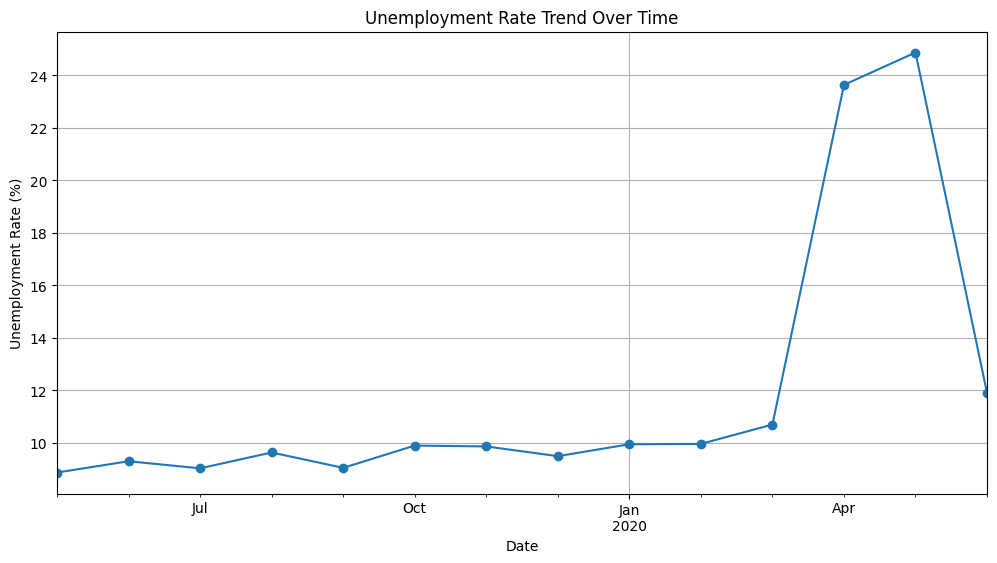


Average Unemployment by Area
Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


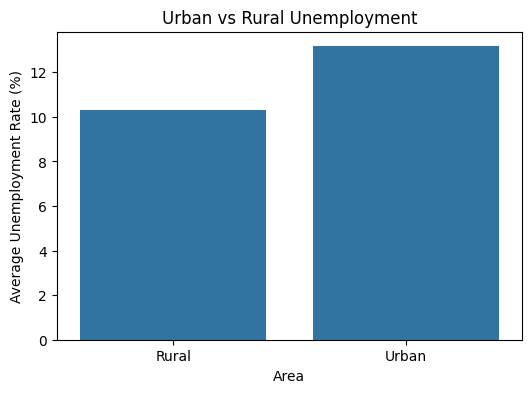


Top 10 States with Highest Unemployment
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


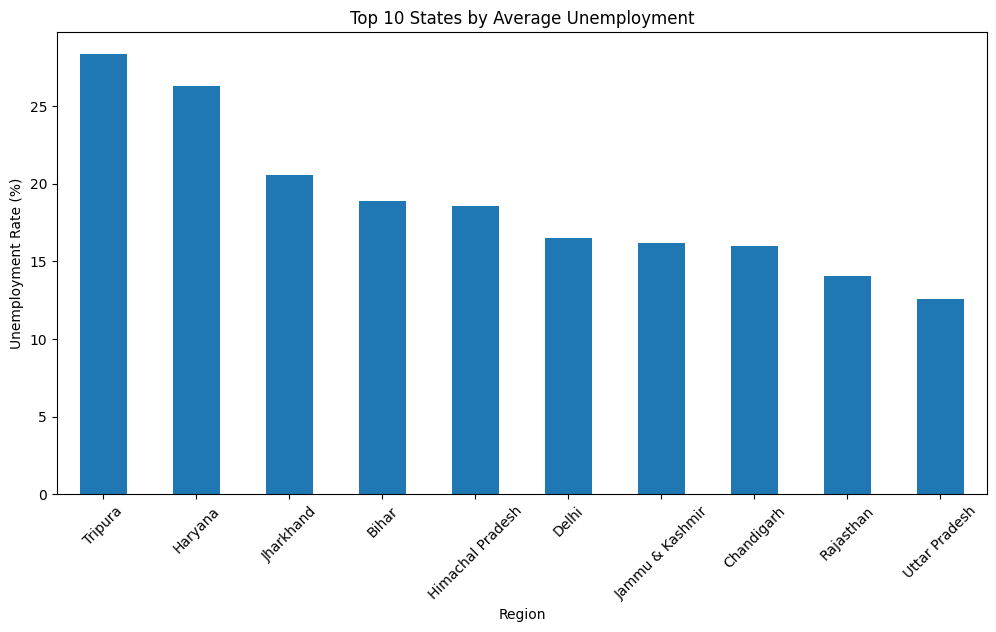


Average Unemployment Before COVID:
9.51 %

Average Unemployment During COVID:
17.77 %


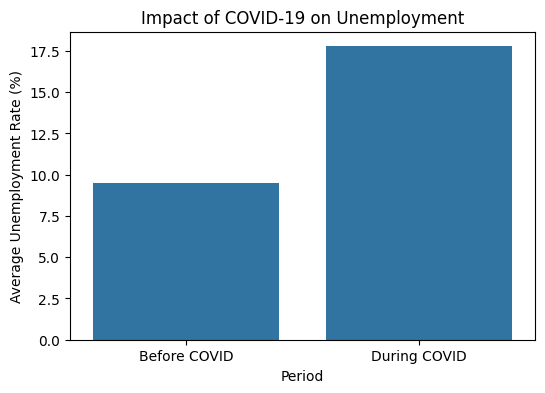

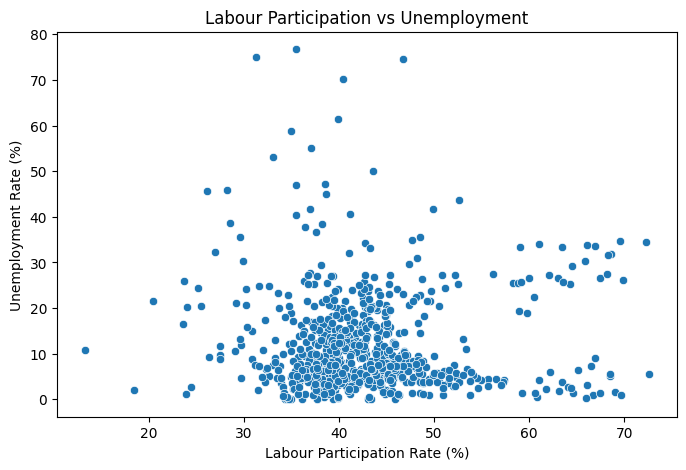

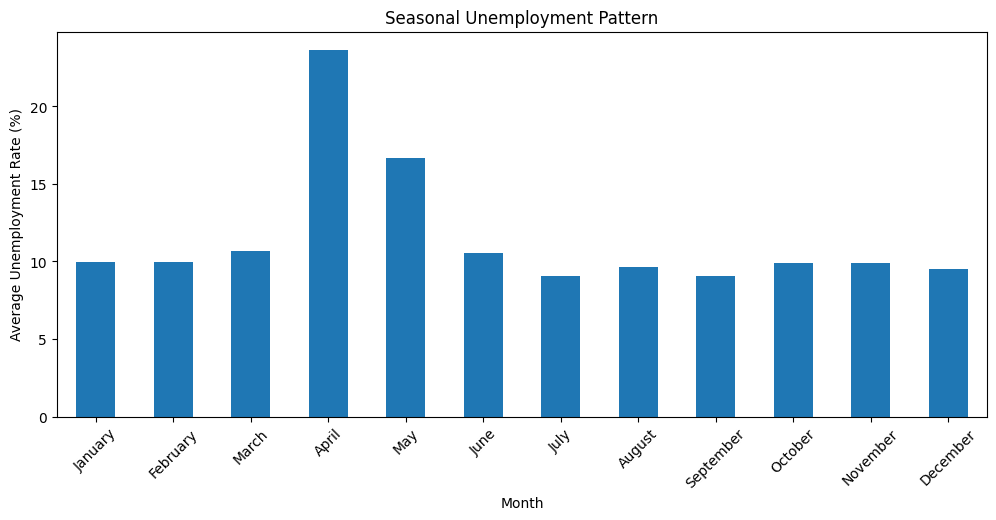


KEY INSIGHTS

1. Average unemployment rate = 11.79%

2. Urban areas generally show higher unemployment
   than rural areas.

3. COVID-19 caused a significant increase
   in unemployment rates.

4. April and May 2020 recorded the highest
   unemployment levels due to lockdowns.

5. Some states consistently experienced
   higher unemployment than others.

6. Seasonal variations can be observed
   across different months.



In [2]:
df = pd.read_csv("Unemployment in India.csv")


# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Drop missing values
df.dropna(inplace=True)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("\nDataset Shape:", df.shape)


print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())


avg_unemployment = df['Estimated Unemployment Rate (%)'].mean()

print("\nAverage Unemployment Rate:")
print(round(avg_unemployment, 2), "%")


monthly_unemployment = df.groupby('Date')[
    'Estimated Unemployment Rate (%)'
].mean()

plt.figure(figsize=(12,6))
monthly_unemployment.plot(marker='o')
plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()


area_analysis = df.groupby('Area')[
    'Estimated Unemployment Rate (%)'
].mean()

print("\nAverage Unemployment by Area")
print(area_analysis)

plt.figure(figsize=(6,4))
sns.barplot(
    x=area_analysis.index,
    y=area_analysis.values
)
plt.title("Urban vs Rural Unemployment")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()


state_unemployment = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

print("\nTop 10 States with Highest Unemployment")
print(state_unemployment.head(10))

plt.figure(figsize=(12,6))
state_unemployment.head(10).plot(kind='bar')
plt.title("Top 10 States by Average Unemployment")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()


covid_start = pd.Timestamp("2020-03-01")

before_covid = df[df['Date'] < covid_start]
during_covid = df[df['Date'] >= covid_start]

before_avg = before_covid[
    'Estimated Unemployment Rate (%)'
].mean()

during_avg = during_covid[
    'Estimated Unemployment Rate (%)'
].mean()

print("\nAverage Unemployment Before COVID:")
print(round(before_avg,2), "%")

print("\nAverage Unemployment During COVID:")
print(round(during_avg,2), "%")

# Visualization

covid_comparison = pd.DataFrame({
    'Period': ['Before COVID', 'During COVID'],
    'Unemployment Rate': [before_avg, during_avg]
})

plt.figure(figsize=(6,4))
sns.barplot(
    data=covid_comparison,
    x='Period',
    y='Unemployment Rate'
)

plt.title("Impact of COVID-19 on Unemployment")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()


plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Labour Participation vs Unemployment")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.show()


df['Month'] = df['Date'].dt.month_name()

monthly_pattern = df.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_pattern = monthly_pattern.reindex(month_order)

plt.figure(figsize=(12,5))
monthly_pattern.plot(kind='bar')
plt.title("Seasonal Unemployment Pattern")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()


print("\nKEY INSIGHTS")

print(f"""
1. Average unemployment rate = {avg_unemployment:.2f}%

2. Urban areas generally show higher unemployment
   than rural areas.

3. COVID-19 caused a significant increase
   in unemployment rates.

4. April and May 2020 recorded the highest
   unemployment levels due to lockdowns.

5. Some states consistently experienced
   higher unemployment than others.

6. Seasonal variations can be observed
   across different months.
""")